In [20]:
print("Titanic Survival")

Titanic Survival


In [21]:
#Import the required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [22]:
#Dataset Loading
df = pd.read_csv("Titanic-Dataset.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [23]:
#Handling Missing Values
print("Dataset Shape:")
print(df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape:
(891, 12)

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


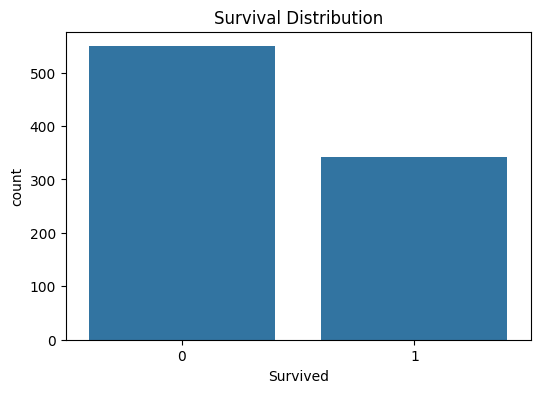

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="Survived",
    data=df
)
plt.title("Survival Distribution")
plt.show()

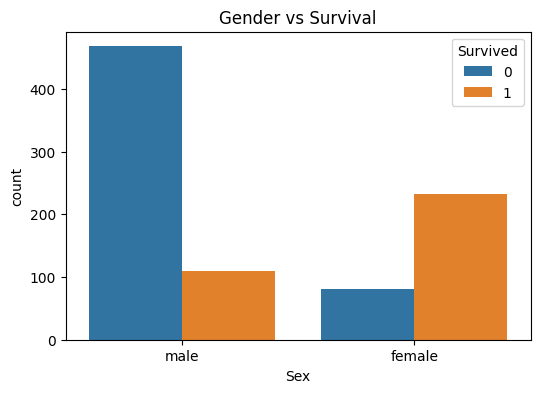

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(
    x="Sex",
    hue="Survived",
    data=df
)
plt.title("Gender vs Survival")
plt.show()

In [36]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

In [27]:
df["Sex"] = df["Sex"].map({
    "male":0,
    "female":1
})
df["Embarked"] = df["Embarked"].map({
    "S":0,
    "C":1,
    "Q":2
})

In [28]:
X = df[
    [
        "Pclass",
        "Sex",
        "Age",
        "SibSp",
        "Parch",
        "Fare",
        "Embarked"
    ]
]

y = df["Survived"]

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [37]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train,y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [31]:
predictions = model.predict(X_test)

In [32]:
accuracy = accuracy_score(
    y_test,
    predictions
)
print("Accuracy:",accuracy)

Accuracy: 0.8268156424581006


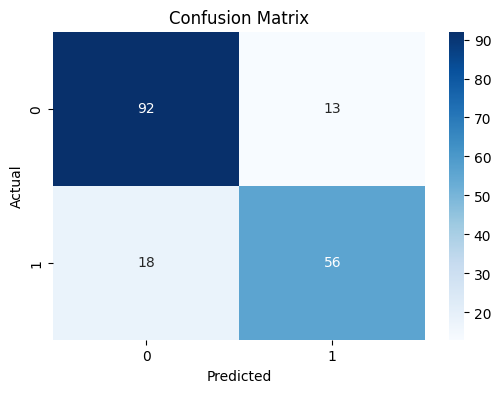

In [33]:
cm = confusion_matrix(
    y_test,
    predictions
)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

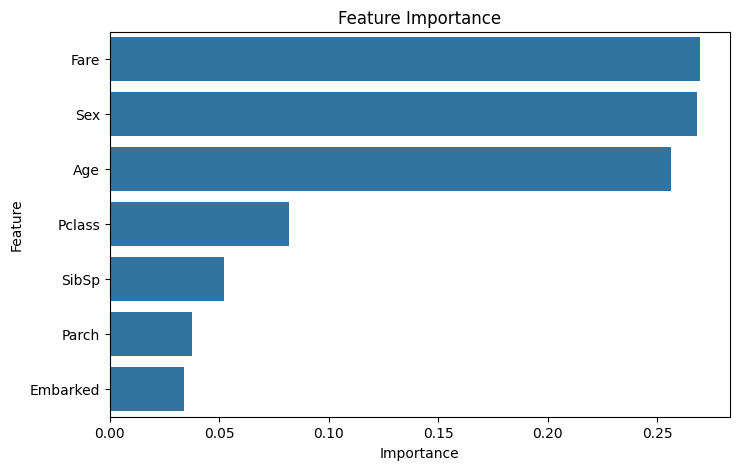

In [34]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)
plt.title("Feature Importance")
plt.show()

In [35]:
print("""
Conclusion:

The Random Forest model was used to predict
whether a passenger survived the Titanic disaster.

The model achieved good accuracy and identified
important factors such as Sex, Fare and Pclass
that influenced survival.
""")


Conclusion:

The Random Forest model was used to predict
whether a passenger survived the Titanic disaster.

The model achieved good accuracy and identified
important factors such as Sex, Fare and Pclass
that influenced survival.

